# 01 · NF-HEDM image processing — median + LoG → SpotsInfo.bin

`midas-nf-preprocess` is the differentiable PyTorch port of the C
`ProcessImagesCombined` stage. It turns raw NF detector frames into the
binary spot-mask (`SpotsInfo.bin`) that the orientation fitter consumes.

This notebook walks the pipeline end-to-end on **synthetic** frames
(no external data, CPU only, a few seconds):

1. Build a tiny synthetic TIFF stack with moving Gaussian "spots".
2. Temporal + spatial median background estimation.
3. Laplacian-of-Gaussian (LoG) peak enhancement.
4. Connected-component peak detection.
5. Pack detected pixels into a `SpotsBitMask` and write `SpotsInfo.bin`.

Every compute step is autograd-alive on the `filtered` / `spot_prob`
tensors — we demonstrate that at the end.

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')   # macOS libomp guard
os.environ.setdefault('MIDAS_NF_PREPROCESS_DEVICE', 'cpu')

import tempfile
from pathlib import Path

import numpy as np
import torch
import tifffile
import matplotlib.pyplot as plt

from midas_nf_preprocess import __version__
from midas_nf_preprocess.process_images import (
    ProcessParams,
    ProcessImagesPipeline,
    FrameResult,
    SpotsBitMask,
    temporal_median,
    spatial_median,
    build_log_kernel,
    apply_log,
    find_peaks,
    label_components,
)
print('midas-nf-preprocess', __version__, '| torch', torch.__version__, '| device cpu')

midas-nf-preprocess 0.1.1 | torch 2.11.0 | device cpu


## 1. Build a synthetic TIFF stack

We write a small NF "scan": a single detector distance, a handful of
frames, each containing one Gaussian spot that drifts across the
detector as ω advances (mimicking a diffraction spot sweeping through
the Bragg condition). A flat background of 100 counts is added so the
median-subtraction step has something to remove.

This mirrors the synthetic-dataset helper used in the package's own
`tests/process_images/test_pipeline.py`.

In [2]:
def gaussian_blob(H, W, cz, cy, sigma=2.5, amp=800.0, dtype=torch.float64):
    z = torch.arange(H, dtype=dtype).view(-1, 1)
    y = torch.arange(W, dtype=dtype).view(1, -1)
    return amp * torch.exp(-((z - cz) ** 2 + (y - cy) ** 2) / (2 * sigma ** 2))

H = W = 64
N_FRAMES = 6
ws = Path(tempfile.mkdtemp(prefix='nf_preproc_'))
for j in range(N_FRAMES):
    cz, cy = 12 + j * 5, 14 + j * 4              # spot drifts frame-to-frame
    frame = (100.0 + gaussian_blob(H, W, cz, cy)).clamp(0, 65535)
    tifffile.imwrite(ws / f'img_{j:06d}.tif', frame.numpy().astype(np.uint16))

print('workspace :', ws)
print('frames    :', sorted(p.name for p in ws.glob('*.tif')))

workspace : /var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/nf_preproc_zvgk75ur
frames    : ['img_000000.tif', 'img_000001.tif', 'img_000002.tif', 'img_000003.tif', 'img_000004.tif', 'img_000005.tif']


saved /var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/nf_preproc_zvgk75ur/raw_stack.png


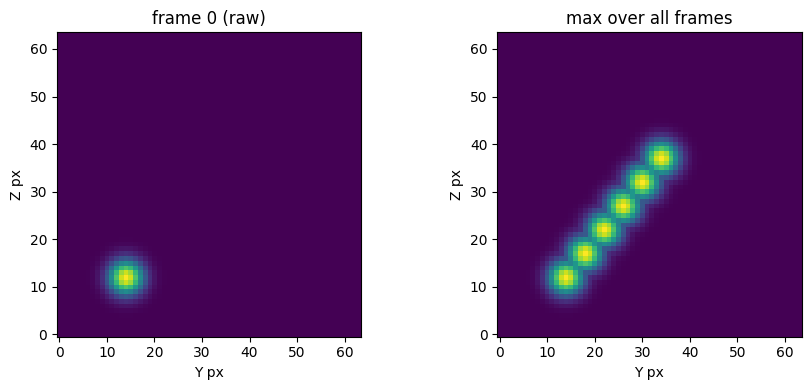

In [3]:
# Quick look at the raw stack (max-projection across frames).
stack = torch.stack([
    torch.as_tensor(tifffile.imread(ws / f'img_{j:06d}.tif').astype(np.float64))
    for j in range(N_FRAMES)
])
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(stack[0], origin='lower', cmap='viridis'); ax[0].set_title('frame 0 (raw)')
ax[1].imshow(stack.amax(0), origin='lower', cmap='viridis'); ax[1].set_title('max over all frames')
for a in ax: a.set_xlabel('Y px'); a.set_ylabel('Z px')
plt.tight_layout(); plt.savefig(ws / 'raw_stack.png', dpi=110)
print('saved', ws / 'raw_stack.png')

## 2. Temporal + spatial median background

NF background removal has two parts:

* **temporal median** — per-pixel median across all frames in the stack.
  Because the spot moves, the per-pixel median is dominated by the flat
  background, so subtracting it isolates the moving spot.
* **spatial median** — a small `(2r+1)×(2r+1)` running median that
  suppresses salt-and-pepper / hot-pixel noise within each frame.

temporal-median background range: 100.0 .. 100.0
background-subtracted frame-2 max: 800.0


saved /var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/nf_preproc_zvgk75ur/median.png


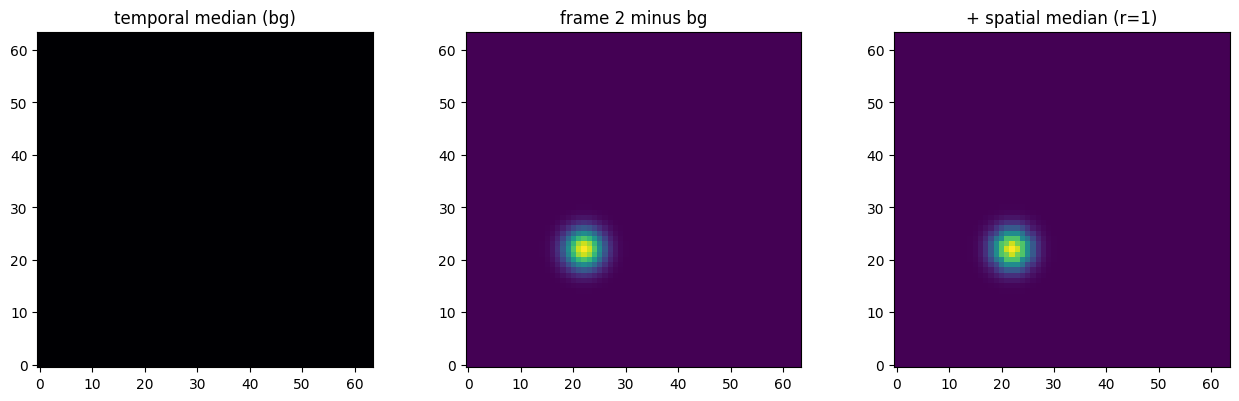

In [4]:
bg = temporal_median(stack)                  # [Z, Y] background estimate
sub = (stack - bg).clamp(min=0)              # background-subtracted stack
sm = spatial_median(sub[2], radius=1)        # spatial median on one frame

print('temporal-median background range:', float(bg.min()), '..', float(bg.max()))
print('background-subtracted frame-2 max:', float(sub[2].max()))

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(bg, origin='lower', cmap='magma');       ax[0].set_title('temporal median (bg)')
ax[1].imshow(sub[2], origin='lower', cmap='viridis'); ax[1].set_title('frame 2 minus bg')
ax[2].imshow(sm, origin='lower', cmap='viridis');     ax[2].set_title('+ spatial median (r=1)')
plt.tight_layout(); plt.savefig(ws / 'median.png', dpi=110)
print('saved', ws / 'median.png')

## 3. Laplacian-of-Gaussian peak enhancement

The LoG kernel is a blob detector: it produces a strong negative
response at the centre of a bright Gaussian spot of matched scale. The
pipeline builds the kernel from `LoGMaskRadius` and `sigma` (here we
call the primitive directly).

LoG kernel shape: (9, 9) | response range: -67.5 .. 1.0
saved /var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/nf_preproc_zvgk75ur/log.png


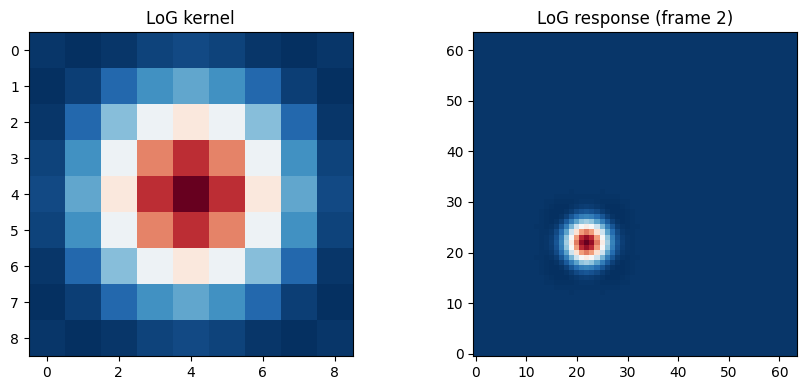

In [5]:
log_kernel = build_log_kernel(radius=4, sigma=2.5, dtype=torch.float64)
log_resp = apply_log(sub[2], log_kernel)        # apply_log takes a [Z, Y] image
print('LoG kernel shape:', tuple(log_kernel.shape), '| response range:',
      round(float(log_resp.min()), 1), '..', round(float(log_resp.max()), 1))

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(log_kernel, cmap='RdBu');               ax[0].set_title('LoG kernel')
ax[1].imshow(log_resp, origin='lower', cmap='RdBu'); ax[1].set_title('LoG response (frame 2)')
plt.tight_layout(); plt.savefig(ws / 'log.png', dpi=110)
print('saved', ws / 'log.png')

## 4. Run the full per-frame / per-layer pipeline

`ProcessImagesPipeline` wires median → LoG → peak detection together.
`ProcessParams` carries the same keys the C param file uses
(`MedFiltRadius`, `LoGMaskRadius`, `GaussFiltRadius`, `DoLoGFilter`, …).
We point it at our TIFF workspace and run one "layer" (one detector
distance).

In [6]:
params = ProcessParams(
    data_directory=str(ws),
    output_directory=str(ws),
    orig_filename='img',
    reduced_filename='proc',
    ext_orig='tif',
    ext_reduced='bin',
    nr_pixels=0,
    nr_pixels_y=W,
    nr_pixels_z=H,
    nr_files_per_distance=N_FRAMES,
    n_distances=1,
    do_log_filter=1,
    log_mask_radius=4,
    sigma=2.5,
    mean_filt_radius=1,
)
pipe = ProcessImagesPipeline(params, device='cpu')
print('pipeline device:', pipe.device, '| dtype:', pipe.dtype,
      '| LoG kernels built:', len(pipe._log_kernels))

bitmask = pipe.process_layer(layer_nr=1)
print('bits set across the layer:', bitmask.count_bits())

pipeline device: cpu | dtype: torch.float64 | LoG kernels built: 2


bits set across the layer: 1374


frame 2 -> connected components (spots): 2
saved /var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/nf_preproc_zvgk75ur/frame_result.png


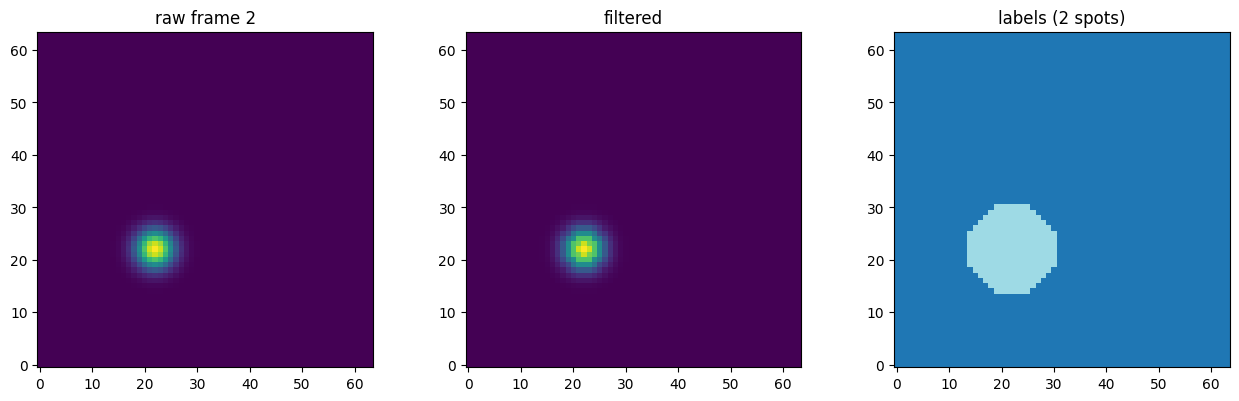

In [7]:
# Inspect a single processed frame: filtered image, labels, peak count.
frame2 = stack[2]
median2 = bg
result: FrameResult = pipe.process_frame(2, frame2, median2, layer_nr=1)
print('frame 2 -> connected components (spots):', result.n_spots)

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(frame2, origin='lower', cmap='viridis');                 ax[0].set_title('raw frame 2')
ax[1].imshow(result.filtered.detach(), origin='lower', cmap='viridis'); ax[1].set_title('filtered')
ax[2].imshow(result.labels, origin='lower', cmap='tab20');            ax[2].set_title(f'labels ({result.n_spots} spots)')
plt.tight_layout(); plt.savefig(ws / 'frame_result.png', dpi=110)
print('saved', ws / 'frame_result.png')

## 5. Write `SpotsInfo.bin`

The detected pixels live in a `SpotsBitMask` — one bit per
`(layer, frame, y, z)` location, packed into `uint32` words. This is
the exact on-disk layout the C `FitOrientationOMP` / `midas-nf-fitorientation`
reads back as `SpotsInfo.bin`.

In [8]:
out_path = ws / 'SpotsInfo.bin'
bitmask.write(out_path)
on_disk = out_path.stat().st_size
expected = bitmask.n_words * 4
print('SpotsInfo.bin :', out_path)
print('size on disk  :', on_disk, 'bytes  (n_words * 4 =', expected, ')')
assert on_disk == expected
print('layers x frames x Y x Z =',
      f'{bitmask.n_layers} x {bitmask.nr_files_per_layer} x '
      f'{bitmask.nr_pixels_y} x {bitmask.nr_pixels_z}')

SpotsInfo.bin : /var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/nf_preproc_zvgk75ur/SpotsInfo.bin
size on disk  : 3072 bytes  (n_words * 4 = 3072 )
layers x frames x Y x Z = 1 x 6 x 64 x 64


## 6. Differentiability check

The boundary is: `filtered` and `spot_prob` stay autograd-alive while
`labels` / `n_spots` (the connected-component bookkeeping) are detached.
A gradient flows from the soft spot-probability back to the input
pixels — this is what lets the downstream fitter co-optimise
preprocessing with geometry.

In [9]:
frame = torch.empty(32, 32, dtype=torch.float64).uniform_(0, 100).requires_grad_(True)
median = torch.zeros(32, 32, dtype=torch.float64)
small = ProcessImagesPipeline(
    ProcessParams(nr_pixels=32, log_mask_radius=2, sigma=1.0), device='cpu')
out = small.process_frame(0, frame, median, layer_nr=1)
loss = out.spot_prob.sum()
loss.backward()
print('filtered.requires_grad :', out.filtered.requires_grad)
print('spot_prob.requires_grad:', out.spot_prob.requires_grad)
print('input grad nonzero      :', bool(frame.grad.abs().sum() > 0))

filtered.requires_grad : True
spot_prob.requires_grad: True
input grad nonzero      : True


## What just happened

| Stage | Primitive |
| --- | --- |
| temporal background | `temporal_median` |
| spatial denoise | `spatial_median` |
| blob enhancement | `build_log_kernel` + `apply_log` |
| peak detection | `find_peaks` / `label_components` (inside `process_frame`) |
| spot mask | `SpotsBitMask` → `SpotsInfo.bin` |

`SpotsInfo.bin` is the hand-off to **`midas-nf-fitorientation`**, which
fits crystal orientation (and, in calibration mode, detector geometry)
per voxel against this spot mask. See that package's
`notebooks/01_calibration_deep_dive.ipynb`.